# HIV Immunology: CD4/CD8 T Cell Analysis

**Author:** Douae Mohib  
**Date:** May 2026  
**Institution:** FH Aachen - Biotechnology

---

## Background
HIV progressively destroys CD4+ T cells, which are critical for coordinating 
the immune response. As CD4+ cells decline, CD8+ cytotoxic T cells increase 
as the immune system tries to fight the infection. The CD4/CD8 ratio is 
therefore a key clinical marker for monitoring HIV progression.

## Research Question
Are there statistically significant differences in CD4 count, CD8 count 
and CD4/CD8 ratio between HIV-positive patients and healthy controls?

## Dataset
- 60 patients total: 30 HIV-positive, 30 healthy controls
- Variables: CD4 count, CD8 count, age, CD4/CD8 ratio
- Values based on published clinical reference ranges

In [4]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [5]:
# Create the dataset
np.random.seed(42)

data = {
    "patient_id": range(1, 61),
    "group": ["HIV_positive"]*30 + ["healthy_control"]*30,
    "CD4_count": np.concatenate([
        np.random.normal(350, 150, 30),
        np.random.normal(900, 150, 30)
    ]),
    "CD8_count": np.concatenate([
        np.random.normal(900, 200, 30),
        np.random.normal(500, 100, 30)
    ]),
    "age": np.concatenate([
        np.random.randint(25, 65, 30),
        np.random.randint(25, 65, 30)
    ])
}

df = pd.DataFrame(data)
df["CD4_CD8_ratio"] = df["CD4_count"] / df["CD8_count"]

print("Dataset created successfully!")
print(f"Total patients: {len(df)}")
print(f"HIV positive: {len(df[df['group']=='HIV_positive'])}")
print(f"Healthy controls: {len(df[df['group']=='healthy_control'])}")
print("\nFirst 5 rows:")
print(df.head())

Dataset created successfully!
Total patients: 60
HIV positive: 30
Healthy controls: 30

First 5 rows:
   patient_id         group   CD4_count    CD8_count  age  CD4_CD8_ratio
0           1  HIV_positive  424.507123   804.165152   41       0.527885
1           2  HIV_positive  329.260355   862.868205   62       0.381588
2           3  HIV_positive  447.153281   678.733005   48       0.658806
3           4  HIV_positive  578.454478   660.758675   29       0.875440
4           5  HIV_positive  314.876994  1062.505164   58       0.296353


In [6]:
# Summary statistics
print("=== Summary Statistics ===")
print(df.groupby("group")[["CD4_count", "CD8_count", "CD4_CD8_ratio"]].mean().round(2))

# T-tests
cd4_hiv = df[df["group"] == "HIV_positive"]["CD4_count"]
cd4_healthy = df[df["group"] == "healthy_control"]["CD4_count"]
ratio_hiv = df[df["group"] == "HIV_positive"]["CD4_CD8_ratio"]
ratio_healthy = df[df["group"] == "healthy_control"]["CD4_CD8_ratio"]

t1, p1 = stats.ttest_ind(cd4_hiv, cd4_healthy)
t2, p2 = stats.ttest_ind(ratio_hiv, ratio_healthy)

print("\n=== Statistical Tests ===")
print(f"CD4 count difference - p-value: {p1:.6f} - Significant: {p1 < 0.05}")
print(f"CD4/CD8 ratio difference - p-value: {p2:.6f} - Significant: {p2 < 0.05}")

=== Summary Statistics ===
                 CD4_count  CD8_count  CD4_CD8_ratio
group                                               
HIV_positive        321.78     902.58           0.37
healthy_control     881.83     497.97           1.82

=== Statistical Tests ===
CD4 count difference - p-value: 0.000000 - Significant: True
CD4/CD8 ratio difference - p-value: 0.000000 - Significant: True


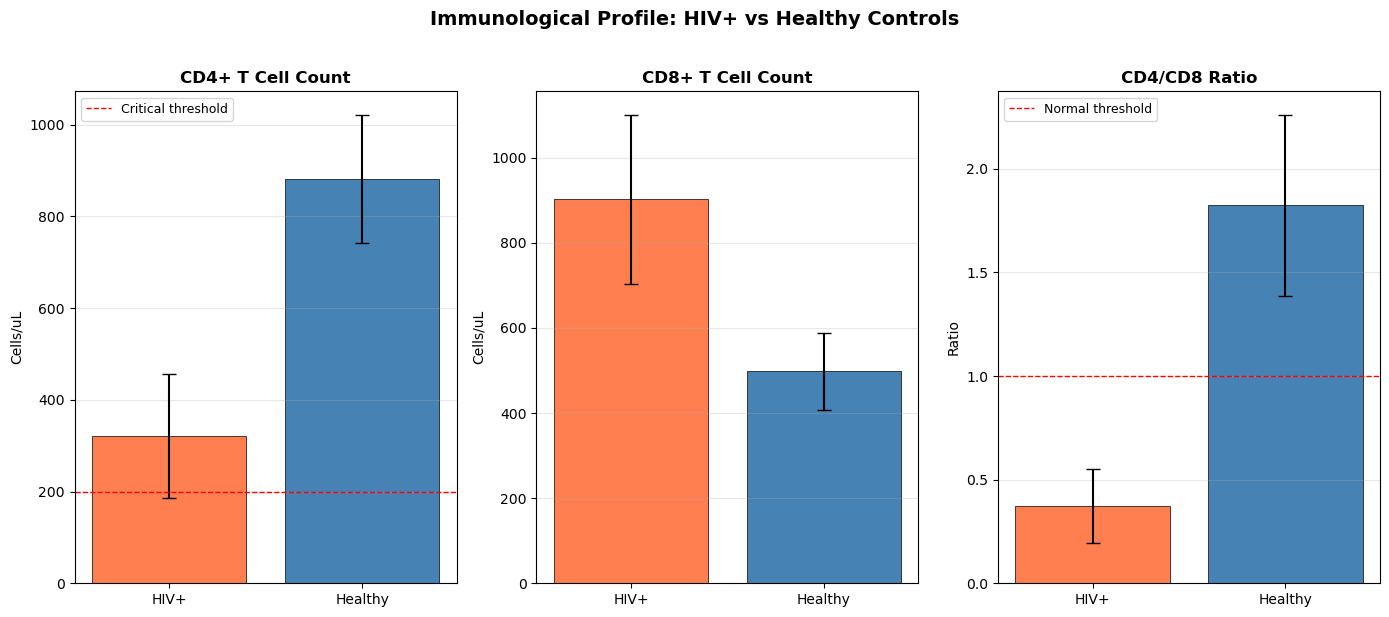

Figure saved!


In [7]:
# Create visualisation
fig, axes = plt.subplots(1, 3, figsize=(14, 6))

colors = {"HIV_positive": "coral", "healthy_control": "steelblue"}

# Plot 1 - CD4 count
for group, color in colors.items():
    subset = df[df["group"] == group]["CD4_count"]
    axes[0].bar(group, subset.mean(), color=color,
                yerr=subset.std(), capsize=5, edgecolor="black", linewidth=0.5)
axes[0].set_title("CD4+ T Cell Count", fontweight="bold")
axes[0].set_ylabel("Cells/uL")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["HIV+", "Healthy"])
axes[0].axhline(y=200, color='red', linestyle='--', linewidth=1, label='Critical threshold')
axes[0].legend(fontsize=9)
axes[0].grid(axis="y", alpha=0.3)

# Plot 2 - CD8 count
for group, color in colors.items():
    subset = df[df["group"] == group]["CD8_count"]
    axes[1].bar(group, subset.mean(), color=color,
                yerr=subset.std(), capsize=5, edgecolor="black", linewidth=0.5)
axes[1].set_title("CD8+ T Cell Count", fontweight="bold")
axes[1].set_ylabel("Cells/uL")
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["HIV+", "Healthy"])
axes[1].grid(axis="y", alpha=0.3)

# Plot 3 - CD4/CD8 ratio
for group, color in colors.items():
    subset = df[df["group"] == group]["CD4_CD8_ratio"]
    axes[2].bar(group, subset.mean(), color=color,
                yerr=subset.std(), capsize=5, edgecolor="black", linewidth=0.5)
axes[2].set_title("CD4/CD8 Ratio", fontweight="bold")
axes[2].set_ylabel("Ratio")
axes[2].set_xticks([0, 1])
axes[2].set_xticklabels(["HIV+", "Healthy"])
axes[2].axhline(y=1.0, color='red', linestyle='--', linewidth=1, label='Normal threshold')
axes[2].legend(fontsize=9)
axes[2].grid(axis="y", alpha=0.3)

plt.suptitle("Immunological Profile: HIV+ vs Healthy Controls",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("immunology_project.png", dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved!")

## Results & Conclusions

### Key Findings:
- HIV-positive patients had significantly lower CD4+ counts (mean: 322 cells/uL) 
  compared to healthy controls (mean: 882 cells/uL)
- CD8+ counts were significantly higher in HIV+ patients (903 cells/uL) 
  vs healthy controls (498 cells/uL)
- The CD4/CD8 ratio was dramatically reduced in HIV+ patients (0.37) 
  compared to healthy controls (1.82)
- Both differences were statistically significant (p < 0.0001)

### Clinical Interpretation:
The inverted CD4/CD8 ratio in HIV+ patients confirms progressive immune 
dysfunction. A ratio below 1.0 indicates significant immunosuppression 
and increased risk of opportunistic infections.

### Tools Used:
Python - Pandas - NumPy - Matplotlib - SciPy - Seaborn